In [1]:
# %%
# %matplotlib inline
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import json
from typing import Dict, List, Tuple, Optional, Union
import os
from crosscoder import BatchTopKCrosscoder
from transformers import AutoTokenizer, AutoModelForCausalLM
from data_utils import get_activations, BOS_TOKEN_ID, USER_TOKEN_ID, ASSISTANT_TOKEN_ID
from datasets import load_dataset

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for CUDA
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
def load_crosscoder_model(model_path: str) -> BatchTopKCrosscoder:
    """Load the trained crosscoder model"""
    # Add PosixPath to safe globals for loading
    from pathlib import PosixPath
    import torch.serialization
    torch.serialization.add_safe_globals([PosixPath])
    
    # Load checkpoint
    checkpoint = torch.load(model_path, weights_only=False)
    
    # Extract model parameters
    d_model = checkpoint['W_encoder_ZF'].shape[0] // 2  # Divide by 2 since it's concatenated
    dict_size = checkpoint['W_encoder_ZF'].shape[1]
    k = checkpoint.get('k', 40)  # Default k if not specified
    
    # Create model and load state
    model = BatchTopKCrosscoder(d_model=d_model, dict_size=dict_size, k=k)
    model.load_state_dict(checkpoint)
    
    return model

# Load the crosscoder model
model_path = "crosscoder-layer14_49152_100_fullshuffle_aux.pt"
crosscoder = load_crosscoder_model(model_path)
crosscoder.to(device)
print(f"Loaded crosscoder model with {crosscoder.dict_size} features")

Loaded crosscoder model with 49152 features


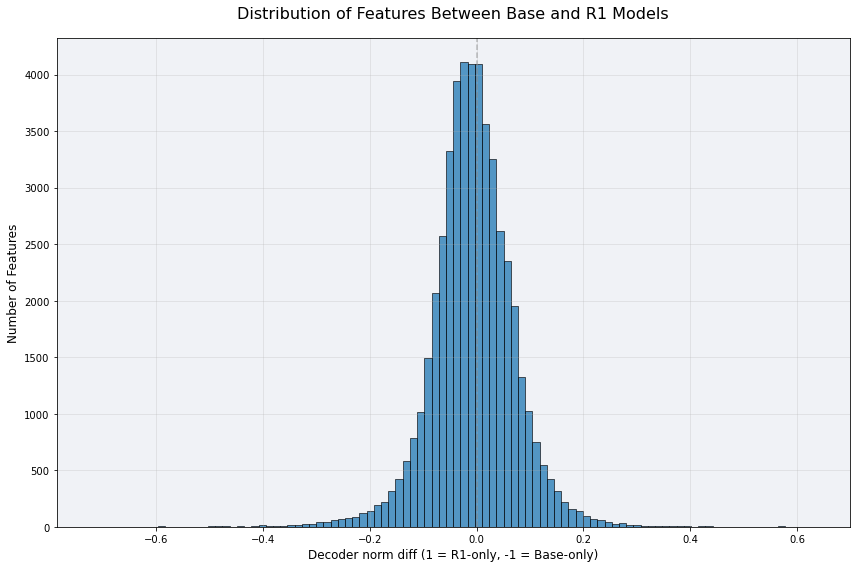

In [4]:
def analyze_decoder_norm_diffs(decoder_A: torch.Tensor, decoder_B: torch.Tensor) -> np.ndarray:
    """
    Analyze decoder norm differences to understand feature exclusivity.
    Returns values between -1 (base model only) and 1 (R1 model only).
    
    Args:
        decoder_A: Decoder weights for base model [dict_size, d_model]
        decoder_B: Decoder weights for R1 model [dict_size, d_model]
        
    Returns:
        Array of norm differences, normalized to [-1, 1]
    """
    # Calculate norms across the d_model dimension
    norm_A = torch.norm(decoder_A, dim=1)  # Shape: [dict_size]
    norm_B = torch.norm(decoder_B, dim=1)  # Shape: [dict_size]
    
    # Calculate normalized difference
    # (B-A)/(B+A) will be:
    # 1 when B >> A (R1 only)
    # -1 when A >> B (base only)
    # 0 when A ≈ B (shared)
    norm_diff = (norm_B - norm_A) / (norm_B + norm_A + 1e-10)
    
    return norm_diff.cpu().numpy()

# Get decoder weights
decoder_weights = crosscoder.W_decoder_FZ.data  # Shape: [dict_size, 2*d_model]
d_model = decoder_weights.shape[1] // 2

# Split decoder weights for base and R1 models
decoder_A = decoder_weights[:, :d_model]  # Shape: [dict_size, d_model]
decoder_B = decoder_weights[:, d_model:]  # Shape: [dict_size, d_model]

# Calculate decoder norm differences
norm_diffs = analyze_decoder_norm_diffs(decoder_A, decoder_B)

# Create a DataFrame for easier analysis
df = pd.DataFrame({'feature_id': np.arange(len(norm_diffs)), 'dec_norm_diff': norm_diffs })

# Plot the distribution of norm differences
plt.figure(figsize=(12, 8))
sns.histplot(data=df['dec_norm_diff'], bins=100)
plt.title('Distribution of Features Between Base and R1 Models', fontsize=16, pad=20)
plt.xlabel('Decoder norm diff (1 = R1-only, -1 = Base-only)', fontsize=12)
plt.ylabel('Number of Features', fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().set_facecolor('#F0F2F6')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Sort features by norm difference
df_sorted = df.sort_values(by='dec_norm_diff')

# Display the most base-exclusive features
print("Most Base-exclusive features:")
display(df_sorted.head(10))

# Display the most R1-exclusive features
print("\nMost R1-exclusive features:")
display(df_sorted.tail(10))

Most Base-exclusive features:


,feature_id,dec_norm_diff
193,193,-0.718330
10946,10946,-0.693451
4783,4783,-0.645346
26020,26020,-0.641761
33867,33867,-0.626092
33174,33174,-0.621748
21466,21466,-0.591893
13125,13125,-0.589734
17037,17037,-0.589200
36234,36234,-0.522014



Most R1-exclusive features:


,feature_id,dec_norm_diff
245,245,0.533536
35164,35164,0.553761
47006,47006,0.564910
17992,17992,0.572656
26749,26749,0.575989
12687,12687,0.582434
47069,47069,0.582665
31882,31882,0.597606
14615,14615,0.618306
25692,25692,0.630714


In [6]:
# Load base model
base_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-Math-1.5B", device_map=device, torch_dtype=torch.bfloat16)
base_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Math-1.5B")

# Load R1 model
r1_tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B")
r1_model = AutoModelForCausalLM.from_pretrained("deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B", device_map=device, torch_dtype=torch.bfloat16)

2025-04-09 22:04:28.844118: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744236268.866636 2223631 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744236268.874232 2223631 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


In [22]:
def get_crosscoder_activations(prompt: str, response: str, layer_num: int = 14, ctx_len=1024):
    """Get crosscoder activations for a given prompt"""
    # Tokenize the prompt
    prompt_tokens = r1_tokenizer(prompt, add_special_tokens=False)["input_ids"]
    
    if response is not None:
        response_tokens = r1_tokenizer(response)["input_ids"][1:]  # remove BOS from response
    else:
        response_tokens = []
    
    # Add special tokens
    if response is not None:
        tokens = [BOS_TOKEN_ID] + [USER_TOKEN_ID] + prompt_tokens + [ASSISTANT_TOKEN_ID] + response_tokens
    else:
        tokens = [BOS_TOKEN_ID] + [USER_TOKEN_ID] + prompt_tokens
    
    tokens = tokens[:ctx_len]
    tokens = torch.tensor(tokens).unsqueeze(0).to(device)
    
    # Get activations from both models
    with torch.no_grad():
        base_activations = get_activations(base_model, tokens, layer_num)
        r1_activations = get_activations(r1_model, tokens, layer_num)
    
    # Concatenate activations
    concatenated_activations = torch.cat([base_activations, r1_activations], dim=-1)
    
    # Reshape to match crosscoder input format
    batch_size, seq_len, hidden_size = concatenated_activations.shape
    reshaped_activations = concatenated_activations.reshape(-1, hidden_size)
    
    # Get crosscoder features
    with torch.no_grad():
        crosscoder_output = crosscoder(reshaped_activations.to(torch.float32))
        features = crosscoder_output["sparse_activations"]
    
    # Reshape features back to [batch_size, seq_len, dict_size]
    features = features.reshape(batch_size, seq_len, -1)
    
    return features, tokens

def visualize_features(prompt: str, response: str, feature_ids: List[int], layer_num: int = 14):
    """Visualize feature activations for a given prompt"""
    features, tokens = get_crosscoder_activations(prompt, response, layer_num)
    
    # Decode tokens
    decoded_tokens = r1_tokenizer.batch_decode(tokens[0])
    
    # Convert feature_ids to integers
    feature_ids = [int(feature_id) for feature_id in feature_ids]
    
    # Get activations for specified features
    feature_activations = {
        f"Feature {feature_id}": features[0, :, feature_id].cpu().numpy() 
        for feature_id in feature_ids
    }
    
    # Create a DataFrame for visualization
    df_viz = pd.DataFrame({'Token': decoded_tokens, **feature_activations})
    
    # Plot activations
    plt.figure(figsize=(15, 5))
    for feature_id in feature_ids:
        plt.plot(df_viz[f"Feature {feature_id}"], label=f"Feature {feature_id}")
    
    # Add token labels
    plt.xticks(range(len(decoded_tokens)), decoded_tokens, rotation=90, ha='right')
    plt.grid(True, alpha=0.3)
    plt.legend()
    # plt.title(f"Feature Activations for: '{prompt}'")
    plt.tight_layout()
    plt.show()
    
    # Display activation values in a table
    # display(df_viz)
    print(df_viz.to_string())

/tmp/ipykernel_2223631/1233716545.py:71: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


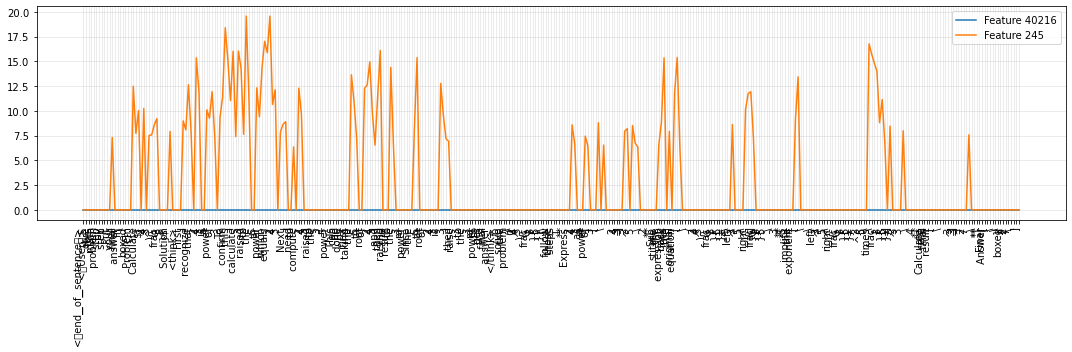

                   Token  Feature 40216  Feature 245
0    <｜end▁of▁sentence｜>            0.0     0.000000
1               <｜User｜>            0.0     0.000000
2                      S            0.0     0.000000
3                   olve            0.0     0.000000
4                   this            0.0     0.000000
5                   math            0.0     0.000000
6                problem            0.0     0.000000
7                   step            0.0     0.000000
8                     by            0.0     0.000000
9                   step            0.0     0.000000
10                     .            0.0     0.000000
11                   Put            0.0     7.309869
12                  your            0.0     0.000000
13                 final            0.0     0.000000
14                answer            0.0     0.000000
15                    in            0.0     0.000000
16                     \            0.0     0.000000
17                 boxed            0.0     0.

In [23]:
prompt = "Solve this math problem step by step. Put your final answer in \\boxed{}. Problem: Calculate: $(243)^{\\frac35}$ Solution: \n<think>\nFirst, I recognize that 243 is a power of 3. To confirm this, I calculate 3 raised to the 5th power, which equals 243.\n\nNext, I need to compute 243 raised to the 3/5 power. This can be done by first taking the 5th root of 243 and then raising the result to the 3rd power.\n\nSince the 5th root of 243 is 3, I then raise 3 to the 3rd power to get the final answer.\n</think>\n\nTo solve the problem \\((243)^{\\frac{3}{5}}\\), follow these steps:\n\n1. **Express 243 as a power of 3:**\n   \\[\n   243 = 3^5\n   \\]\n\n2. **Substitute the expression back into the original equation:**\n   \\[\n   (243)^{\\frac{3}{5}} = \\left(3^5\\right)^{\\frac{3}{5}}\n   \\]\n\n3. **Simplify the exponent:**\n   \\[\n   \\left(3^5\\right)^{\\frac{3}{5}} = 3^{5 \\times \\frac{3}{5}} = 3^3\n   \\]\n\n4. **Calculate the final result:**\n   \\[\n   3^3 = 27\n   \\]\n\n**Final Answer:**\n\\[\n\\boxed{27}\n\\]"
response = None
visualize_features(prompt, response, feature_ids=[df_sorted.iloc[10].feature_id, df_sorted.iloc[-10].feature_id])

/tmp/ipykernel_2223631/1233716545.py:71: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


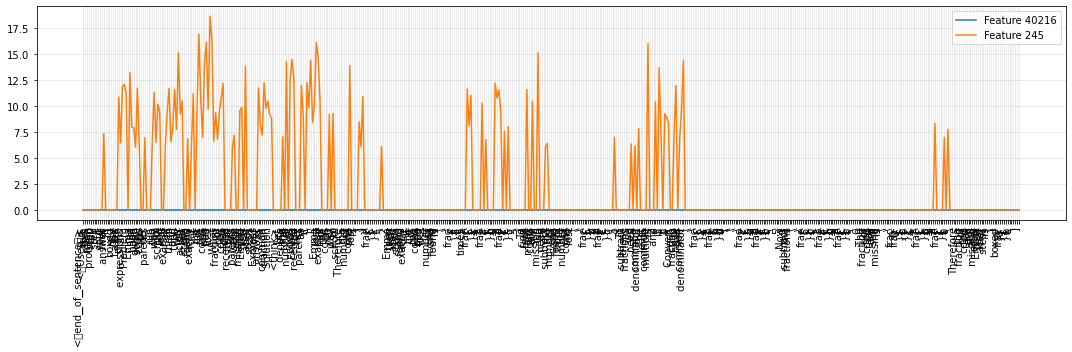

                   Token  Feature 40216  Feature 245
0    <｜end▁of▁sentence｜>            0.0     0.000000
1               <｜User｜>            0.0     0.000000
2                      S            0.0     0.000000
3                   olve            0.0     0.000000
4                   this            0.0     0.000000
5                   math            0.0     0.000000
6                problem            0.0     0.000000
7                   step            0.0     0.000000
8                     by            0.0     0.000000
9                   step            0.0     0.000000
10                     .            0.0     0.000000
11                   Put            0.0     7.349453
12                  your            0.0     0.000000
13                 final            0.0     0.000000
14                answer            0.0     0.000000
15                    in            0.0     0.000000
16                     \            0.0     0.000000
17                 boxed            0.0     0.

In [24]:
prompt = "Solve this math problem step by step. Put your final answer in \\boxed{}. Use LaTeX for math expressions. Problem: Emma had just been given some coins by her parents.  On the way to school she lost exactly half of them, and then by retracing her steps she found exactly four-fifths of the coins she had lost.  What fraction of the coins that she received from her parents were still missing after Emma retraced her steps? Express your answer as a common fraction. Solution: \n<think>\nLet's denote the total number of coins Emma received by her parents as \\( C \\).\n\n1. Emma lost exactly half of the coins on her way to school. Therefore, the number of coins she lost is:\n   \\[\n   \\frac{C}{2}\n   \\]\n\n2. Emma then retraced her steps and found exactly four-fifths of the coins she had lost. The number of coins she found is:\n   \\[\n   \\frac{4}{5} \\times \\frac{C}{2} = \\frac{4C}{10} = \\frac{2C}{5}\n   \\]\n\n3. To find out how many coins are still missing, we need to subtract the number of coins she found from the number of coins she lost:\n   \\[\n   \\frac{C}{2} - \\frac{2C}{5}\n   \\]\n\n4. To subtract these fractions, we need a common denominator. The least common multiple of 2 and 5 is 10. Convert each fraction to have this common denominator:\n   \\[\n   \\frac{C}{2} = \\frac{5C}{10}\n   \\]\n   \\[\n   \\frac{2C}{5} = \\frac{4C}{10}\n   \\]\n\n5. Now, subtract the fractions:\n   \\[\n   \\frac{5C}{10} - \\frac{4C}{10} = \\frac{C}{10}\n   \\]\n\n6. The fraction of the coins that are still missing is:\n   \\[\n   \\frac{\\frac{C}{10}}{C} = \\frac{C}{10C} = \\frac{1}{10}\n   \\]\n\nTherefore, the fraction of the coins that are still missing after Emma retraced her steps is:\n\\[\n\\boxed{\\frac{1}{10}}\n\\]"
response = None
visualize_features(prompt, response, feature_ids=[df_sorted.iloc[10].feature_id, df_sorted.iloc[-10].feature_id])

/tmp/ipykernel_2200587/466535970.py:61: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


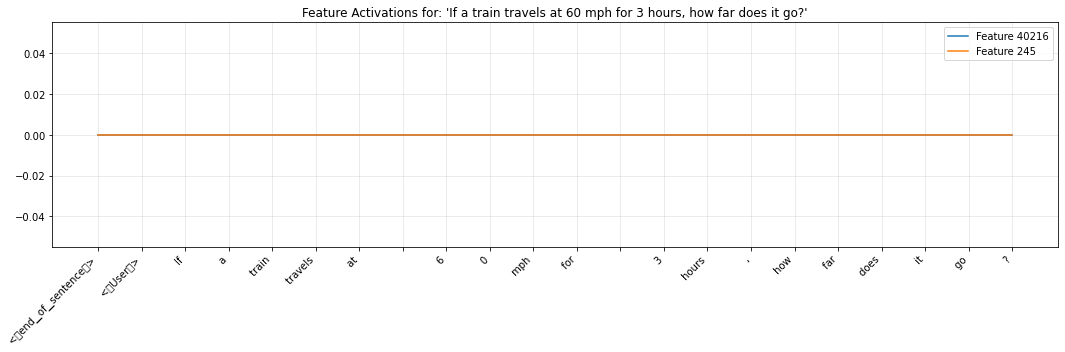

,Token,Feature 40216,Feature 245
0,<｜end▁of▁sentence｜>,0.0,0.0
1,<｜User｜>,0.0,0.0
2,If,0.0,0.0
3,a,0.0,0.0
4,train,0.0,0.0
5,travels,0.0,0.0
6,at,0.0,0.0
7,,0.0,0.0
8,6,0.0,0.0
9,0,0.0,0.0


In [10]:
example = "If a train travels at 60 mph for 3 hours, how far does it go?"
visualize_features(example, feature_ids=[df_sorted.iloc[10].feature_id, df_sorted.iloc[-10].feature_id])

In [23]:
def find_top_activating_tokens(feature_ids: List[int], num_examples: int = 10, limit: int = 10000):
    """Find tokens that most strongly activate specific features
    
    Args:
        feature_ids: List of feature IDs to analyze
        num_examples: Number of top examples to return per feature
        limit: Maximum number of dataset examples to process
    
    Returns:
        Dictionary mapping feature IDs to DataFrames of top activating tokens
    """
    # Convert feature_ids to integers
    feature_ids = [int(feature_id) for feature_id in feature_ids]
    
    # Load the dataset
    dataset = load_dataset("ServiceNow-AI/R1-Distill-SFT", "v1", split="train", streaming=False)
    dataset = dataset.shuffle(seed=42)  
    print(f"Loaded {len(dataset)} examples from dataset")
    
    # Dictionary to store top activations for each feature
    all_top_activations = {feature_id: [] for feature_id in feature_ids}
    
    for i, example in enumerate(tqdm(dataset, total=min(limit, len(dataset)))):
        if i >= limit:
            break
        
        prompt = example["reannotated_messages"][0]["content"]
        response = example["reannotated_messages"][1]["content"]
        
        features, tokens = get_crosscoder_activations(prompt, response)
        
        # Process each feature
        for feature_id in feature_ids:
            # Get activations for this feature
            feature_acts = features[0, :, feature_id].cpu().numpy()
            
            # Find top activating positions
            top_indices = np.argsort(feature_acts)[-num_examples:][::-1]
            
            for idx in top_indices:
                if feature_acts[idx] > 0:  # Only include positive activations
                    token = r1_tokenizer.decode(tokens[0, idx])
                    all_top_activations[feature_id].append({
                        'token': token,
                        'activation': float(feature_acts[idx]),
                        'context': prompt[:100] + "..." if len(prompt) > 100 else prompt
                    })
    
    # Sort and create DataFrames for each feature
    results = {}
    for feature_id in feature_ids:
        # Sort by activation strength
        sorted_activations = sorted(all_top_activations[feature_id], key=lambda x: x['activation'], reverse=True)
        
        # Create DataFrame with top examples
        df = pd.DataFrame(sorted_activations[:num_examples])
        
        # Store in results
        results[feature_id] = df
        
        # Display results
        print(f"\n--- Top activations for Feature {feature_id} ---")
        display(df)
    
    return results

In [24]:
most_base_exclusive_feature_ids = [int(df_sorted.iloc[i].feature_id) for i in range(20)]
print(f"Analyzing features: {most_base_exclusive_feature_ids} (base-exclusive)")
feature_results = find_top_activating_tokens(most_base_exclusive_feature_ids)

Analyzing features: [193, 10946, 4783, 26020, 33867, 33174, 21466, 13125, 17037, 36234, 40216, 25777, 27043, 26548, 37729, 47529, 33226, 2768, 33581, 5682] (base-exclusive)


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/51 [00:00<?, ?it/s]

Loaded 1679162 examples from dataset


100%|██████████| 10000/10000 [21:42<00:00,  7.68it/s]

...

,token,activation,context
0,the,27.541176,Given the function $f(x) = \sin(2x + \frac{\pi...
1,the,25.418777,Given the function $f(x)=2\sin x\cos x+2 \sqrt...
2,the,24.744537,Given the function $f(x) = \sin(2x + \frac{\pi...
3,the,24.044724,Given that the function $f(x) = \sqrt{3}\sin\o...
4,the,22.750639,Given the functions $f(x)=2\cos^{2}(x+\frac{\p...
5,Translate,22.692438,Given the function $f(x) = \sin(2x + \frac{\pi...
6,the,22.647825,Given the function $f(x) = 4\cos\left(\frac{\p...
7,the,22.632067,Given the function $f(x)=2\sin({ωx+\frac{π}{3}...
8,the,22.225935,Given the function $f(x) = 4\sin(\omega x - \f...
9,$,22.210394,Given the function $f(x)=2\sin (ωx+φ) (ω > 0)$...



--- Top activations for Feature 33581 ---


,token,activation,context
0,<think>,1000.601501,chào
1,Ƙ,925.094360,Ƙirƙiri labarin don kanun labarai mai zuwa: Ko...
2,ஹ,881.544006,ஹுரோஷிமா தினம் எப்போது அனுசரிக்கப்படுகிறது?
3,🇰,654.737915,🇰🇬 Манас эпосу 📚\nМанастагы көркөм фактылар ме...
4,.,511.405945,INT. BOARDROOM - DAY\n\nA group of executives ...
5,:,487.060608,Q: You are given a text of the tweet and a cor...
6,:,485.171814,Q: Test for natural language inference.\nPremi...
7,:,485.171814,"Q: Premise: ""The man with a shaved head and ni..."
8,:,485.171814,"Q: Premise: ""A couple waiting at a crosswalk i..."
9,:,485.171814,"Q: Title: The Coulter Doctrine: ""Do as I say, ..."



--- Top activations for Feature 5682 ---


,token,activation,context
0,0,38.050640,A soap maker sources two types of wildflower p...
1,simpl,37.557350,If $z=a+\frac{i}{1-i}(a∈R)$ is an imaginary nu...
2,simpl,36.641788,"Given that point $P(1,1)$ is the midpoint of c..."
3,1,36.637665,"To further implement the work of ""moral, intel..."
4,_,36.469563,Given an arithmetic sequence $\{a\_n\}$ with a...
5,{\,36.279213,Calculate:<br/>$(1)-1^{4}-7\div [2-\left(-3\ri...
6,simpl,36.264736,An ellipse C is defined by the equation $$\fra...
7,0,35.903103,A safety-conscious chemistry teacher is prepar...
8,\,35.754333,Find the minimum value of\n\[ 3x^2 + 3xy + y^2...
9,0,35.692249,As a science grant officer with a passion for ...


In [ ]:
most_r1_exclusive_feature_ids = [int(df_sorted.iloc[-i-1].feature_id) for i in range(20)]
print(f"Analyzing features: {most_r1_exclusive_feature_ids} (R1-exclusive)")
feature_results = find_top_activating_tokens(most_r1_exclusive_feature_ids)

Analyzing features: [25692, 14615, 31882, 47069, 12687, 26749, 17992, 47006, 35164, 245, 29008, 38737, 24654, 43782, 41940, 2179, 22582, 27180, 11874, 4759] (R1-exclusive)


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/51 [00:00<?, ?it/s]

Loaded 1679162 examples from dataset


 42%|████▏     | 4240/10000 [19:27<23:49,  4.03it/s]